In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if 'google.colab' in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Семинар 2 · Ноутбук 3
# Метрики качества точечных прогнозов

Выбор метрики — не формальность, а капризный процесс, зависящий от характера ваших данных.
Выбрав не ту метрику, можно случайно провозгласить победителем модель, которая на самом деле
бесконтрольно завышает прогнозы, или отбросить алгоритм, который идеально решает бизнес-задачу.
Разные метрики оптимизируют **разные статистики** (квадратичные тянут прогноз к среднему,
абсолютные — к медиане) и по-разному «ломаются» на нулях, выбросах, трендах и сезонности.

🔍 В 2009 году команда, победившая в конкурсе Netflix Prize, улучшила RMSE на 10%. Netflix так
и не внедрил их алгоритм: выигрыш в метрике не переводился в бизнес-эффект, а модель оказалась
слишком громоздкой. **Метрика — это не цель, а компас.**

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Как посчитать стандартные метрики на реальных прогнозах — и чем для этого различаются `statsforecast`/`utilsforecast`, `sktime` и `etna` |
| 2 | Что делать, когда разные метрики называют лучшими разные модели — и как понять, из-за чего именно они «спорят» |
| 3 | Как устроен «зоопарк» метрик из статей: у каждой метрики есть характер — сильные стороны и типичный сценарий поломки |

> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит обратить
> внимание особо: там прячутся типичные ошибки новичков.

---
# 1. Метрики на реальных прогнозах

## 1.1. Тест и ошибки прогноза

Точность оценивают на **отложенных** (hold-out) данных — обычно последние ~20% ряда,
которые модель не видела при обучении. Важно различать две вещи:

- **остатки** — расхождения на *обучающей* выборке, одношаговые ($e_t = y_t - \hat y_{t|t-1}$);
- **ошибки прогноза** — расхождения на *тесте*, могут быть многошаговыми:
  $e_{n+h} = y_{n+h} - \hat y_{n+h\,|\,n}$.

Метрику всегда считают по ошибкам прогноза, а не по остаткам: хорошая подгонка на обучении
ещё не означает хорошего прогноза.

**Семейства метрик** (по способу нормировки ошибки):

- **масштабозависимые** — в единицах ряда:
  $\mathrm{MAE}=\mathrm{mean}(|e_t|)$, $\mathrm{RMSE}=\sqrt{\mathrm{mean}(e_t^2)}$.
  Интуитивны, но их нельзя сравнивать между рядами разного масштаба;
- **процентные** — безразмерны:
  $\mathrm{MAPE}=\mathrm{mean}\!\left(100\,|e_t/y_t|\right)$.
  Сравнимы между рядами, но ломаются при $y_t\approx 0$ и асимметричны;
- **масштабированные** (Hyndman–Koehler) — делят ошибку на MAE наивного прогноза
  на обучении: $\mathrm{MASE}$. Значение $<1$ читается как «лучше наивного».

Ниже сначала получим прогнозы, а затем посчитаем все четыре метрики одной командой.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

from statsforecast import StatsForecast
from statsforecast.models import (HistoricAverage, Naive, SeasonalNaive,
                                   RandomWalkWithDrift, WindowAverage,
                                   AutoARIMA, AutoETS)
from utilsforecast.losses import rmse, mae, mape, mase, smape
from utilsforecast.evaluation import evaluate

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


## 1.2. Интерфейс `StatsForecast`: несколько моделей сразу

`StatsForecast` работает не с одним рядом-массивом, а с «длинным» (панельным) датафреймом
из трёх обязательных колонок:

- `unique_id` — идентификатор ряда (у нас ряд один — `"beer"`);
- `ds` — метка времени (`datetime`);
- `y` — значение.

Список моделей передаётся в конструктор, и `forecast(df, h)` обучает их **все сразу** и
возвращает прогнозы в одном датафрейме — по колонке на модель. Это удобнее, чем вызывать
`.fit().predict()` для каждой модели по отдельности, и ровно так метрики обычно и считают:
на общем наборе прогнозов от нескольких кандидатов.

## 1.3. Пример с сезонностью: производство пива

Обучаемся на данных до конца 2007 года, прогнозируем 10 кварталов (2008–2010)
четырьмя простыми методами.

In [2]:
aus_production = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/aus-production.csv", sep=";")
recent = aus_production[aus_production["Quarter"] >= "1992"].copy()

# приводим 'YYYY Qn' к datetime и переходим к панельному формату statsforecast
recent["ds"] = pd.PeriodIndex(recent["Quarter"].str.replace(" ", ""),
                              freq="Q").to_timestamp()
recent["unique_id"] = "beer"

beer_train = recent[recent["Quarter"] < "2008"]
beer_test = recent[recent["Quarter"] >= "2008"]

train_df = beer_train[["unique_id", "ds", "Beer"]].rename(columns={"Beer": "y"})
train_df.tail()

,unique_id,ds,y
203,beer,2006-10-01,491
204,beer,2007-01-01,427
205,beer,2007-04-01,383
206,beer,2007-07-01,394
207,beer,2007-10-01,473


In [3]:
models = [HistoricAverage(), Naive(),
          SeasonalNaive(season_length=4), RandomWalkWithDrift()]

sf = StatsForecast(models=models, freq="QS")
beer_fc = sf.forecast(df=train_df, h=10)   # обучаем все 4 модели и прогнозируем разом
beer_fc

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD
0,beer,2008-01-01,435.375,473.0,427.0,473.476196
1,beer,2008-04-01,435.375,473.0,383.0,473.952393
2,beer,2008-07-01,435.375,473.0,394.0,474.428558
3,beer,2008-10-01,435.375,473.0,473.0,474.904755
4,beer,2009-01-01,435.375,473.0,427.0,475.380951
5,beer,2009-04-01,435.375,473.0,383.0,475.857147
6,beer,2009-07-01,435.375,473.0,394.0,476.333344
7,beer,2009-10-01,435.375,473.0,473.0,476.809509
8,beer,2010-01-01,435.375,473.0,427.0,477.285706
9,beer,2010-04-01,435.375,473.0,383.0,477.761902


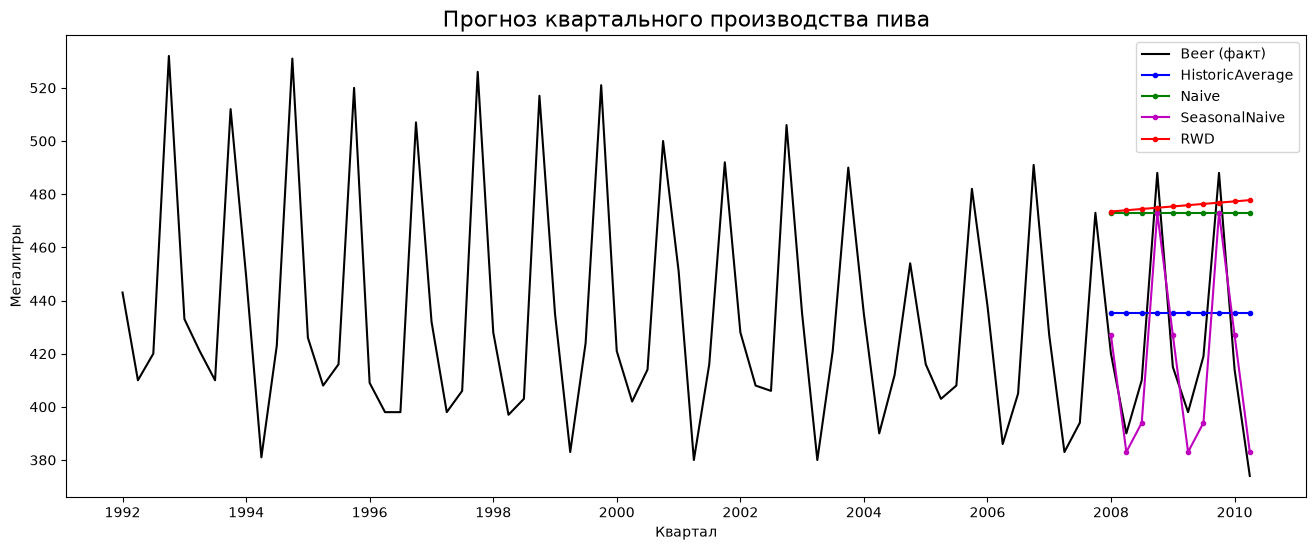

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent["ds"], recent["Beer"], "k-", label="Beer (факт)")
for col, color in zip(["HistoricAverage", "Naive", "SeasonalNaive", "RWD"],
                      ["b", "g", "m", "r"]):
    ax.plot(beer_fc["ds"], beer_fc[col], color + "-o", ms=3, label=col)
ax.set_title("Прогноз квартального производства пива", fontsize=16)
ax.set_ylabel("Мегалитры"); ax.set_xlabel("Квартал")
ax.legend()
plt.show()

## 1.4. Точность через `evaluate()` и подсветка лучшего метода

Метрики считаем функцией `evaluate()` из `utilsforecast`: ей передаём датафрейм прогнозов
с добавленной колонкой факта `y`, список метрик и (для `MASE`) обучающую выборку. Результат —
таблица, где **строки — метрики, а столбцы — методы**.

Чтобы сразу видеть, какой метод лучше, подсветим в каждой строке минимальное значение
(все четыре метрики — «чем меньше, тем лучше»). Для `MASE` сезонность задаём через
`partial(..., seasonality=4)`.

In [5]:
def add_actuals(forecast_df, test_df):
    """Добавляет колонку факта `y` к прогнозам по ключу (unique_id, ds)."""
    y = test_df[["unique_id", "ds", "Beer"]].rename(columns={"Beer": "y"})
    return forecast_df.merge(y, on=["unique_id", "ds"])


def styled_accuracy(eval_df):
    """Таблица метрик: строки — метрики, жирным — лучший метод в строке."""
    tbl = eval_df.drop(columns="unique_id").set_index("metric")
    return (tbl.style
               .highlight_min(axis=1, props="font-weight:bold")
               .format("{:.3f}"))


# для MASE нужна сезонность; имя задаём явно, чтобы колонка называлась 'mase'
mase_q = partial(mase, seasonality=4)
mase_q.__name__ = "mase"

In [6]:
beer_eval = evaluate(add_actuals(beer_fc, beer_test),
                     metrics=[rmse, mae, mape, mase_q],
                     train_df=train_df)
styled_accuracy(beer_eval)

,HistoricAverage,Naive,SeasonalNaive,RWD
metric,,,,
rmse,38.447,62.693,14.311,64.901
mae,34.825,57.400,13.400,58.876
mape,0.083,0.142,0.032,0.146
mase,2.435,4.014,0.937,4.117


Все четыре метрики согласованно выбирают **`SeasonalNaive`** — для выраженно сезонного
ряда сезонный наивный прогноз бьёт и среднее, и обычный наивный, и дрейф. Когда метрики
«спорят» между собой — это сигнал, что у моделей разные типы ошибок и стоит смотреть
на характер ошибок, а не только на одно число.

## 1.5. Несезонный пример: акции Google

Обучение — 2015 год, прогноз — на весь 2016-й. Сезонности нет, поэтому берём три метода
(`SeasonalNaive` не нужен), а для `MASE` сезонность равна 1 (обычный наивный масштаб).

In [7]:
google = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/GOOGL.csv", parse_dates=["Date"])
google["unique_id"] = "googl"
google = google.rename(columns={"Date": "ds", "Close": "y"})

g_train = google[google["ds"] <= "2015-12-31"][["unique_id", "ds", "y"]]
g_test = google[google["ds"] > "2015-12-31"][["unique_id", "ds", "y"]]

sf_g = StatsForecast(
    models=[HistoricAverage(), Naive(), RandomWalkWithDrift()], freq="D")
g_fc = sf_g.forecast(df=g_train, h=len(g_test))

mase_1 = partial(mase, seasonality=1)
mase_1.__name__ = "mase"

g_eval = evaluate(g_fc.merge(g_test, on=["unique_id", "ds"]),
                  metrics=[rmse, mae, mape, mase_1], train_df=g_train)
styled_accuracy(g_eval)

,HistoricAverage,Naive,RWD
metric,,,
rmse,6.018,2.109,2.606
mae,5.961,1.940,2.410
mape,0.161,0.053,0.066
mase,16.222,5.280,6.559


Для «почти случайного блуждания» (цена акции) лучший метод — обычный **`Naive`**:
завтра ≈ сегодня. И снова все метрики согласны между собой.

## 1.6. Три экосистемы: utilsforecast, sktime, etna

На практике метрики почти никогда не пишут руками — берут готовые. В экосистеме курса их три:

| Библиотека | Формат данных | Как задана метрика | Пачкой | Возвращает |
|---|---|---|---|---|
| `utilsforecast` | панельный датафрейм (`unique_id/ds/y`) | функция (`rmse`, `mae`, `mape`, `mase`, `smape`) | `evaluate(df, metrics=[...])` | таблица метрика × модель |
| `sktime` | массивы/`pd.Series` | класс с параметрами в конструкторе (`MeanAbsoluteScaledError(sp=4)`) | вручную, по одной модели | число |
| `etna` | `TSDataset` (wide, по сегментам) | класс (`MAE()`, `SMAPE()`, …) | `Pipeline.backtest(metrics=[...])` | словарь `{сегмент: значение}` |

⚠️ **Тонкость с `MASE` в `sktime`.** Сезонный период `sp` задаётся **в конструкторе**
(`MeanAbsoluteScaledError(sp=4)`), а не в вызове. Если передать `sp` в вызов, он молча
игнорируется, и масштаб посчитается по несезонному наивному (`sp=1`). Ниже — сверка `MASE`
для `SeasonalNaive` тремя способами; все три должны совпасть.

In [8]:
from sktime.performance_metrics.forecasting import (
    MeanAbsoluteError, MeanAbsolutePercentageError, MeanAbsoluteScaledError)

y_true = beer_test["Beer"].values
y_pred = beer_fc["SeasonalNaive"].values
y_tr = train_df["y"].values

# 1) utilsforecast (значение MASE из таблицы beer_eval)
uf_mase = beer_eval.loc[beer_eval["metric"] == "mase", "SeasonalNaive"].item()

# 2) sktime, sp в КОНСТРУКТОРЕ (правильно)
sk_mase = MeanAbsoluteScaledError(sp=4)(y_true, y_pred, y_train=y_tr)

# 3) вручную: MAE модели / MAE сезонного наивного на обучении
scale = np.mean(np.abs(y_tr[4:] - y_tr[:-4]))
manual_mase = np.mean(np.abs(y_true - y_pred)) / scale

print(f"MASE  utilsforecast : {uf_mase:.6f}")
print(f"MASE  sktime (sp=4) : {sk_mase:.6f}")
print(f"MASE  вручную       : {manual_mase:.6f}")

print(f"\nMAE  (sktime) : {MeanAbsoluteError()(y_true, y_pred):.4f}")
print(f"MAPE (sktime) : {MeanAbsolutePercentageError()(y_true, y_pred):.4f}")

MASE  utilsforecast : 0.937063
MASE  sktime (sp=4) : 0.937063
MASE  вручную       : 0.937063

MAE  (sktime) : 13.4000
MAPE (sktime) : 0.0317


Все три числа совпадают — значит, `sp` действительно попал в конструктор. Это и есть
главный риск при смене библиотеки: одна и та же формула в разных API включается по-разному,
и молчаливая ошибка в параметре не бросит исключение, а тихо подменит результат.

### `etna`: третья экосистема — `TSDataset` и `Pipeline`

`etna` устроена иначе, чем `statsforecast`/`sktime`: она не считает метрику по массиву
«факт/прогноз», а работает с объектом `TSDataset` — тем же самым типом, в котором хранятся
и факт, и прогноз, и (при бэктесте) сразу несколько фолдов. Мы просто оборачиваем **уже
посчитанный** прогноз `SeasonalNaive` из раздела 1.3 в `TSDataset`, чтобы сравнить с теми же
`MAE`/`MAPE`, но теперь через API `etna`.

In [9]:
from etna.datasets import TSDataset
from etna.metrics import MAE as eMAE, MAPE as eMAPE, SMAPE as eSMAPE, WAPE as eWAPE
from etna.metrics import Sign, MaxDeviation

# TSDataset хранит данные в "широком" формате: колонки timestamp/segment/target
beer_actual_df = pd.DataFrame({
    "timestamp": beer_test["ds"].values, "segment": "beer", "target": beer_test["Beer"].values})
beer_pred_df = pd.DataFrame({
    "timestamp": beer_fc["ds"].values, "segment": "beer", "target": beer_fc["SeasonalNaive"].values})

beer_actual_ts = TSDataset(TSDataset.to_dataset(beer_actual_df), freq="QS")
beer_pred_ts = TSDataset(TSDataset.to_dataset(beer_pred_df), freq="QS")

# метрики etna — это классы, вызов возвращает словарь {сегмент: значение} (mode="macro" по умолчанию)
print(f"MAE  (etna) : {eMAE()(y_true=beer_actual_ts, y_pred=beer_pred_ts)['beer']:.4f}")
print(f"MAPE (etna) : {eMAPE()(y_true=beer_actual_ts, y_pred=beer_pred_ts)['beer']:.4f}")

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:49: UserWarning: etna[chronos] is not available, to install it, run `pip install etna[chronos]`
  warnings.warn("etna[chronos] is not available, to install it, run `pip install etna[chronos]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-pack

MAE  (etna) : 13.4000
MAPE (etna) : 3.1685


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/datasets/tsdataset.py:377: UserWarning: You probably set wrong freq. Discovered freq in you data is QS-OCT, you set QS-JAN
  warnings.warn(
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/datasets/tsdataset.py:377: UserWarning: You probably set wrong freq. Discovered freq in you data is QS-OCT, you set QS-JAN
  warnings.warn(


`MAE` (13.4) совпадает с тем, что дали `utilsforecast`/`sktime` в разделе 1.4 — метрика та
же, просто обёрнута в другой интерфейс. А вот `MAPE` совпадает не всегда: дело в конвенциях,
и дальше мы увидим случай, где расхождение куда заметнее.

🔍 **Словарь, а не число.** Вызов метрики etna возвращает `{"beer": ...}`, а не голое число —
потому что `TSDataset` может хранить сразу много сегментов (рядов). У всех метрик etna есть
параметр `mode`: `"macro"` (по умолчанию) усредняет по сегментам, `"per-segment"` возвращает
ответ по каждому сегменту отдельно. Если забыть про это и попытаться сравнить словарь с
числом напрямую — получите ошибку типов, а не тихую подмену, что уже не так опасно.

🔍 **В `etna` 3.0 нет `MASE` и `RMSSE`.** Доступны `MAE, MSE, RMSE, MSLE, MedAE, MAPE, SMAPE,
WAPE, R2` (+ интервальные `Coverage`, `Width`) и метрики смещения `Sign`, `MaxDeviation` — но
не масштабированные ошибки Хиндмана–Коэлера. Если в проекте на `etna` нужен именно `MASE` —
его считают через `utilsforecast`/`sktime` или вручную, как в ячейке выше.

### Одна и та же sMAPE — в трёх библиотеках

Возьмём игрушечный пример: факт `[100, 50, 10]`, прогноз `[120, 40, 12]` — и посчитаем
`sMAPE`, `MAPE` и `WAPE` во всех трёх экосистемах.

In [10]:
from utilsforecast.losses import smape as uf_smape, mape as uf_mape

toy_y, toy_f = np.array([100.0, 50.0, 10.0]), np.array([120.0, 40.0, 12.0])
toy_df = pd.DataFrame({
    "unique_id": "toy", "ds": pd.date_range("2020-01-01", periods=3, freq="D"),
    "y": toy_y, "model": toy_f})

uf_smape_val = uf_smape(toy_df, models=["model"]).iloc[0]["model"]
uf_mape_val = uf_mape(toy_df, models=["model"]).iloc[0]["model"]

sk_smape_val = MeanAbsolutePercentageError(symmetric=True)(toy_y, toy_f)
sk_mape_val = MeanAbsolutePercentageError()(toy_y, toy_f)

toy_actual_ts = TSDataset(TSDataset.to_dataset(pd.DataFrame({
    "timestamp": toy_df["ds"], "segment": "toy", "target": toy_y})), freq="D")
toy_pred_ts = TSDataset(TSDataset.to_dataset(pd.DataFrame({
    "timestamp": toy_df["ds"], "segment": "toy", "target": toy_f})), freq="D")
etna_smape_val = eSMAPE()(y_true=toy_actual_ts, y_pred=toy_pred_ts)["toy"]
etna_mape_val = eMAPE()(y_true=toy_actual_ts, y_pred=toy_pred_ts)["toy"]
etna_wape_val = eWAPE()(y_true=toy_actual_ts, y_pred=toy_pred_ts)["toy"]

print(f"{'':14}{'sMAPE':>10}{'MAPE':>10}{'WAPE':>10}")
print(f"{'utilsforecast':14}{uf_smape_val:>10.4f}{uf_mape_val:>10.4f}{'—':>10}")
print(f"{'sktime':14}{sk_smape_val:>10.4f}{sk_mape_val:>10.4f}{'—':>10}")
print(f"{'etna':14}{etna_smape_val:>10.4f}{etna_mape_val:>10.4f}{etna_wape_val:>10.4f}")

                   sMAPE      MAPE      WAPE
utilsforecast     0.0976    0.2000         —
sktime            0.1953    0.2000         —
etna             19.5286   20.0000    0.2000


Разброс в **200 раз** для «одной и той же» метрики: `utilsforecast` использует формулу sMAPE
с делением знаменателя пополам и отдаёт долю (0.0976), `sktime` — формулу с ×2, тоже долю
(0.1953), а `etna` — те же 0.1953, но в процентах (19.53). При этом внутри одной библиотеки
конвенции тоже не совпадают: `MAPE` в `etna` — это проценты, а `WAPE` — доля (0.2, не 20).

🔍 **Число метрики без указания библиотеки и версии бессмысленно.** Это первое, что стоит
проверять, сравнивая свой результат с чужим отчётом или лидербордом: то же название метрики
может значить долю, проценты или другую формулу знаменателя.

### `Sign` и `MaxDeviation`: смещение, а не только величина ошибки

Величина ошибки (`MAE`, `RMSE`) ничего не говорит о её **направлении**. Модель может стабильно
завышать или занижать прогноз — и это часто важнее среднего размаха ошибки. `Sign` считает
долю положительных ошибок (`y - ŷ > 0`, то есть модель недооценила факт): значение далеко от
0.5 указывает на систематическое смещение. `MaxDeviation` — максимум **накопленного**
расхождения (кумулятивной суммы ошибок) — показывает, не «уезжает» ли прогноз всё дальше от
факта по ходу горизонта.

In [11]:
print(f"Sign         (etna) : {Sign()(y_true=beer_actual_ts, y_pred=beer_pred_ts)['beer']:.3f}")
print(f"MaxDeviation (etna) : {MaxDeviation()(y_true=beer_actual_ts, y_pred=beer_pred_ts)['beer']:.3f}")

Sign         (etna) : 0.200
MaxDeviation (etna) : 74.000


`Sign = 0.2` означает, что лишь в 20% точек факт превысил прогноз — `SeasonalNaive`
систематически чуть занижает пиковые кварталы. Прежде чем усреднять ошибку по модулю,
полезно взглянуть именно на такое разложение «смещение / разброс»: это пригодится в разделе 2,
где мы разберём случаи, в которых метрики расходятся во мнениях именно из-за смещения.

---
# 2. Когда метрики спорят

До сих пор все метрики единодушно выбирали одну и ту же модель. На практике это скорее
исключение: у метрик разные «слепые зоны», и стоит проверить пару-тройку кандидатов —
рейтинги начинают расходиться. Разберём три сценария, в которых это происходит, и протокол
того, что делать, когда метрики не сошлись во мнении.

## 2.1. Реальные данные: продажи лекарств (`a10.csv`)

Ряд с выраженным трендом и сильной сезонностью — хороший кандидат, чтобы увидеть
рассогласование не на игрушечном примере, а на реальном прогнозе. Обучаем 7 моделей
`statsforecast` на всех месяцах, кроме последних 24, и прогнозируем эти 24 месяца.

In [12]:
a10 = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/a10.csv")
a10["ds"] = pd.to_datetime(a10["Month"])
a10["unique_id"] = "drug"
a10 = a10.rename(columns={"Cost": "y"})

h = 24
a10_train = a10.iloc[:-h][["unique_id", "ds", "y"]]
a10_test = a10.iloc[-h:][["unique_id", "ds", "y"]]

a10_models = [HistoricAverage(), Naive(), SeasonalNaive(season_length=12),
              RandomWalkWithDrift(), WindowAverage(window_size=12),
              AutoARIMA(season_length=12), AutoETS(season_length=12)]
sf_a10 = StatsForecast(models=a10_models, freq="MS")
a10_fc = sf_a10.forecast(df=a10_train, h=h)

mase_12 = partial(mase, seasonality=12)
mase_12.__name__ = "mase"
a10_eval = evaluate(a10_fc.merge(a10_test, on=["unique_id", "ds"]),
                    metrics=[rmse, mae, mape, smape, mase_12], train_df=a10_train)
styled_accuracy(a10_eval)

,HistoricAverage,Naive,SeasonalNaive,RWD,WindowAverage,AutoARIMA,AutoETS
metric,,,,,,,
rmse,12.961,6.426,4.942,5.613,5.564,2.991,3.056
mae,12.497,5.430,4.498,4.595,4.591,2.599,2.578
mape,0.565,0.231,0.202,0.194,0.194,0.116,0.115
smape,0.397,0.136,0.115,0.112,0.112,0.062,0.063
mase,12.329,5.357,4.437,4.533,4.529,2.564,2.544


Возьмём две пары моделей из этой таблицы и посмотрим, кто у кого выигрывает по каждой метрике.

In [13]:
def winners(eval_df, model_a, model_b):
    out = {}
    for _, row in eval_df.iterrows():
        a, b = row[model_a], row[model_b]
        out[row["metric"]] = model_a if a < b else model_b
    return pd.Series(out, name=f"{model_a} vs {model_b}")

pd.DataFrame([winners(a10_eval, "SeasonalNaive", "WindowAverage"),
              winners(a10_eval, "AutoETS", "AutoARIMA")])

,rmse,mae,mape,smape,mase
SeasonalNaive vs WindowAverage,SeasonalNaive,SeasonalNaive,WindowAverage,WindowAverage,SeasonalNaive
AutoETS vs AutoARIMA,AutoARIMA,AutoETS,AutoETS,AutoARIMA,AutoETS


Обе пары показывают рассогласование. `SeasonalNaive` против `WindowAverage` — разрыв учебный,
на глаз заметный: `SeasonalNaive` выигрывает по `RMSE`/`MAE`/`MASE`, но проигрывает по
`MAPE`/`sMAPE`. Пара `AutoETS` против `AutoARIMA` интереснее — это верхушка таблицы, где выбор
лучшей модели **буквально зависит от того, какую метрику записали в ТЗ**: `AutoARIMA` выигрывает
по `RMSE` и `sMAPE`, а `AutoETS` — по `MAE`, `MASE` и `MAPE`.

Посмотрим, откуда берётся разногласие в первой паре — через график прогнозов и поточечных ошибок.

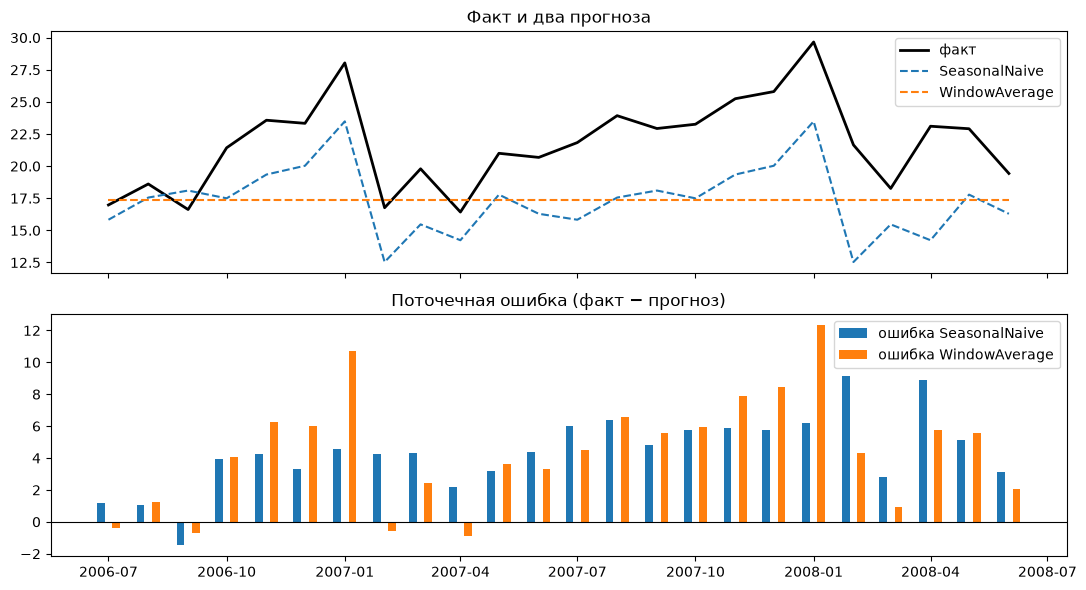

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(a10_test["ds"], a10_test["y"], "k-", label="факт", linewidth=2)
axes[0].plot(a10_fc["ds"], a10_fc["SeasonalNaive"], "--", label="SeasonalNaive")
axes[0].plot(a10_fc["ds"], a10_fc["WindowAverage"], "--", label="WindowAverage")
axes[0].legend()
axes[0].set_title("Факт и два прогноза")

err_sn = a10_test["y"].values - a10_fc["SeasonalNaive"].values
err_wa = a10_test["y"].values - a10_fc["WindowAverage"].values
width = 6
axes[1].bar(a10_test["ds"] - pd.Timedelta(days=width), err_sn, width=width, label="ошибка SeasonalNaive")
axes[1].bar(a10_test["ds"] + pd.Timedelta(days=width), err_wa, width=width, label="ошибка WindowAverage")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend()
axes[1].set_title("Поточечная ошибка (факт − прогноз)")
plt.tight_layout()
plt.show()

`SeasonalNaive` ошибается по-крупному **на сезонных пиках**, где факт велик, — там же и
абсолютная, и относительная ошибка выглядят предсказуемо, но в процентах промах на большом
факте «размывается». `WindowAverage` ошибается ровнее, но систематически смещён на **низких**
значениях сезонного цикла, где та же абсолютная ошибка даёт куда больший процент. Отсюда и
разногласие: `RMSE`/`MAE` взвешивают ошибки в единицах ряда и им важны крупные абсолютные
промахи на пиках, а `MAPE`/`sMAPE` взвешивают ошибки в процентах и им важнее промахи на низких
значениях. **Метрики не «спорят» случайно — они по-разному взвешивают одни и те же ошибки, и
разногласие показывает, где именно модели различаются.**

## 2.2. Прерывистый спрос: MAE выбирает модель-«ноль»

Соберём синтетический ряд склада: ~70% нулей и редкие всплески спроса. Сравним две наивные
модели — константу 0 и константу, равную среднему значению ряда.

In [15]:
rng = np.random.default_rng(7)
n_id = 30
y_id = np.zeros(n_id)
spike_idx = rng.choice(n_id, size=9, replace=False)
y_id[spike_idx] = rng.uniform(8, 12, size=9)

pred_zero = np.zeros(n_id)
pred_mean = np.full(n_id, y_id.mean())

pd.DataFrame({
    "MAE":  [np.mean(np.abs(y_id - pred_zero)), np.mean(np.abs(y_id - pred_mean))],
    "RMSE": [np.sqrt(np.mean((y_id - pred_zero) ** 2)), np.sqrt(np.mean((y_id - pred_mean) ** 2))],
}, index=["модель «ноль»", "модель «среднее»"])

,MAE,RMSE
модель «ноль»,3.012740,5.523951
модель «среднее»,4.217835,4.630058


`MAE` называет лучшей модель **«всегда ноль»** — она никогда сильно не промахивается на частых
нулях, а редкие всплески дают лишь несколько крупных ошибок, которые для *среднего* модуля не
так страшны. `RMSE`, наоборот, наказывает модель «ноль» за эти редкие, но большие промахи
сильнее — потому что возводит их в квадрат — и предпочитает модель «среднее».

Причина та же, что и в разделе 1.1: абсолютные метрики целятся в **медиану** условного
распределения, а для прерывистого ряда медиана почти всегда равна нулю — значит, MAE
систематически будет на стороне модели, которая просто предсказывает ноль. Квадратичные
метрики целятся в **среднее**, которое сдвинуто редкими всплесками вверх. Практический вывод
лонгрида: для прерывистых рядов берите `RMSE`/`RMSSE`, избегайте чистого `MAE`, а `MAPE` здесь
вообще не определена (факт часто равен нулю).

## 2.3. Агрегаты и масштаб: ловушка MAPE

Два товара очень разного масштаба: 100 000 и 100 000 000 единиц. Две модели ошибаются в
абсолюте на одну и ту же суммарную величину — но по-разному распределяют ошибку между товарами.

In [16]:
def toy_mape(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.mean(np.abs(f - a) / np.maximum(np.abs(a), eps))

def toy_wape(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.sum(np.abs(f - a)) / np.sum(np.abs(a))

products_actual = np.array([100000, 100000000])
scale_rows = {}
for label, f in [("модель A (промах на мелком товаре)", np.array([120000, 101000000])),
                 ("модель B (промах на крупном товаре)", np.array([110000, 105000000]))]:
    f = np.asarray(f, float)
    scale_rows[label] = {
        "суммарная ошибка": int(np.sum(f) - np.sum(products_actual)),
        "MAPE": toy_mape(products_actual, f),
        "WAPE": toy_wape(products_actual, f),
    }
pd.DataFrame(scale_rows).T

,суммарная ошибка,MAPE,WAPE
модель A (промах на мелком товаре),1020000.0,0.105,0.01019
модель B (промах на крупном товаре),5010000.0,0.075,0.05005


Модель B ошиблась в абсолюте **в 5 раз сильнее** (5 млн против 1 млн), но её `MAPE` ниже —
крупный промах пришёлся на товар большого масштаба, где он «размывается» в проценты. `WAPE`
считает иначе: у неё общий знаменатель на оба товара, поэтому она честно отражает, что у модели
B суммарная ошибка больше. Для бизнес-агрегатов (объёмы, деньги) это ровно та ловушка, ради
которой существует `WAPE` — подробный разбор в разделе 3.

## 2.4. Протокол: что делать, когда метрики спорят

1. Проверить, не расходятся ли **конвенции библиотек** (раздел 1.6) — половина «противоречий»
   отсюда: убедитесь, что сравниваете действительно одну и ту же формулу.
2. Разложить ошибку на **смещение и разброс** (`ME`/`Sign`/`MaxDeviation` из раздела 1.6):
   часто одна из моделей просто систематически смещена, и это виднее, чем среднее по модулю.
3. Построить **график поточечных ошибок**, как в разделе 2.1 — понять, где именно модели
   различаются: на пиках, на низких значениях, в конце горизонта.
4. **Согласовать loss обучения с финальной метрикой прогноза.** Не оценивайте один и тот же
   прогноз множеством метрик как будто это разные независимые проверки; если метрик несколько
   и они важны — обучайте (или отбирайте) модель отдельно под каждую.
5. Задать бизнесу вопрос: что дороже — пропустить пик спроса или ошибиться в спокойный день?
   Ответ на него обычно и определяет, какая метрика в семье «главная».
6. Оставшиеся метрики использовать как **sanity check**, а не как второй критерий отбора —
   иначе выбор модели превращается в лотерею «какая метрика удобнее в этот раз».

🔍 Ровно об этом — «парадокс точности» Netflix Prize из вступления: улучшение метрики на 10%
не гарантирует бизнес-эффекта. Метрика — компас, который помогает сравнивать кандидатов, а не
цель сама по себе.

---
# 3. «Зоопарк» метрик на сценариях

Чтобы почувствовать *характер* каждой метрики, прогоним их через набор искусственных
сценариев: равномерные ошибки, одиночные выбросы, систематическая недо-/переоценка,
значения около нуля. На реальных данных все эти эффекты перемешаны — а на игрушечных
примерах свойство каждой метрики видно в чистом виде.

Сначала — общая инфраструктура: 12 скалярных сценариев (факт, прогноз) и 7 наборов
из 10 точек с разными паттернами ошибок.

In [17]:
# 12 скалярных сценариев (факт, прогноз, подпись)
scenarios = [
    (30, 30,  'факт=30, прогноз=30 (идеально)'),
    (20, 30,  'факт=20, прогноз=30 (переоценка)'),
    (20, 10,  'факт=20, прогноз=10 (недооценка)'),
    (30, 300, 'факт=30, прогноз=300 (большая ошибка)'),
    (10, 20,  'факт=10, прогноз=20 (переоценка)'),
    (30, 20,  'факт=30, прогноз=20 (недооценка)'),
    (1,  2,   'факт=1, прогноз=2 (переоценка)'),
    (2,  1,   'факт=2, прогноз=1 (недооценка)'),
    (0.1, 1,  'факт=0.1, прогноз=1 (переоценка)'),
    (1, 0.1,  'факт=1, прогноз=0.1 (недооценка)'),
    (0, 1,    'факт=0, прогноз=1 (переоценка)'),
    (1, 0,    'факт=1, прогноз=0 (недооценка)'),
]

def scenario_table(func, name):
    """Применяет метрику func(actual, forecast) ко всем скалярным сценариям."""
    idx = [s[2] for s in scenarios]
    vals = [func(s[0], s[1]) for s in scenarios]
    return pd.DataFrame({name: vals}, index=idx)

In [18]:
# 7 наборов из 10 точек с разными паттернами ошибок
def make(actual, forecast):
    return pd.DataFrame({'Actual': actual, 'Forecast': forecast})

patterns = {
    'равномерные положительные ошибки':
        make([3,4,5,6,7,8,9,10,11,12], [1,2,3,4,5,6,7,8,9,10]),
    'варьирование положительных ошибок':
        make([2,3,4,5,6,9,10,11,12,13], [1,2,3,4,5,6,7,8,9,10]),
    'одна большая положительная ошибка':
        make([1,2,3,4,5,6,7,8,9,30], [1,2,3,4,5,6,7,8,9,10]),
    'одна большая + / одна большая -':
        make([1,2,3,4,5,6,25,8,9,30], [1,2,3,4,5,6,45,8,9,10]),
    'равномерные отрицательные ошибки':
        make([1,2,3,4,5,6,7,8,9,10], [3,4,5,6,7,8,9,10,11,12]),
    'варьирование отрицательных ошибок':
        make([1,2,3,4,5,6,7,8,9,10], [2,3,4,5,6,9,10,11,12,13]),
    'одна большая отрицательная ошибка':
        make([1,2,3,4,5,6,7,8,9,10], [1,2,3,4,5,6,7,8,9,30]),
}

def pattern_table(funcs):
    """funcs: dict {имя_метрики: func(actual, forecast)}."""
    rows = {}
    for pname, dfp in patterns.items():
        rows[pname] = {mname: f(dfp['Actual'], dfp['Forecast'])
                       for mname, f in funcs.items()}
    return pd.DataFrame(rows).T

## 3.1. Масштабозависимые: MSE, RMSE, MAE, MdAE

$\mathrm{MSE}=\mathrm{mean}(e_t^2)$, $\mathrm{RMSE}=\sqrt{\mathrm{MSE}}$,
$\mathrm{MAE}=\mathrm{mean}|e_t|$, $\mathrm{MdAE}=\mathrm{median}|e_t|$.

Из-за возведения в квадрат `RMSE` **сильнее штрафует крупные ошибки** — один выброс тянет
её вверх сильнее, чем `MAE`. Медианная `MdAE` вообще почти игнорирует одиночный выброс
(медиана нечувствительна к «хвосту»). Отсюда практическое правило: минимизируя `MSE/RMSE`,
модель тянется к **среднему** условного распределения, а минимизируя `MAE` — к его
**медиане**. Все четыре измеряются в единицах ряда, поэтому несопоставимы между рядами
разного масштаба.

Это не абстрактное различие: в разделе 2.2 мы уже видели, к чему приводит выбор между
средним и медианой на прерывистом ряду — `MAE` там называет лучшей модель, которая всегда
прогнозирует ноль, именно потому что целится в медиану, а не в среднее.

Сначала сверим свои реализации со `scikit-learn` на реальном ряду.

In [19]:
from sklearn.metrics import (mean_squared_error, root_mean_squared_error,
                             mean_absolute_error)

def mse(a, f):   return np.mean((np.asarray(a) - np.asarray(f)) ** 2)
def rmse_(a, f): return np.sqrt(mse(a, f))
def mae_(a, f):  return np.mean(np.abs(np.asarray(a) - np.asarray(f)))
def mdae(a, f):  return np.median(np.abs(np.asarray(a) - np.asarray(f)))

data = pd.read_csv('https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/results.csv', sep=';',
                   parse_dates=['date'], dayfirst=True, index_col='date')
print("MSE  (свой / sklearn): %.3f / %.3f" %
      (mse(data['fact'], data['pred']),
       mean_squared_error(data['fact'], data['pred'])))
print("RMSE (свой / sklearn): %.3f / %.3f" %
      (rmse_(data['fact'], data['pred']),
       root_mean_squared_error(data['fact'], data['pred'])))
print("MAE  (свой / sklearn): %.3f / %.3f" %
      (mae_(data['fact'], data['pred']),
       mean_absolute_error(data['fact'], data['pred'])))

MSE  (свой / sklearn): 0.354 / 0.354
RMSE (свой / sklearn): 0.595 / 0.595
MAE  (свой / sklearn): 0.510 / 0.510


In [20]:
pattern_table({'RMSE': rmse_, 'MAE': mae_, 'MdAE': mdae})

,RMSE,MAE,MdAE
равномерные положительные ошибки,2.000000,2.0,2.0
варьирование положительных ошибок,2.236068,2.0,2.0
одна большая положительная ошибка,6.324555,2.0,0.0
одна большая + / одна большая -,8.944272,4.0,0.0
равномерные отрицательные ошибки,2.000000,2.0,2.0
варьирование отрицательных ошибок,2.236068,2.0,2.0
одна большая отрицательная ошибка,6.324555,2.0,0.0


На паттернах видно: `MAE` и `MdAE` не отличают «одну большую ошибку» от «равномерных» —
для них важна только суммарная/типичная величина. А `RMSE` на выбросе резко подскакивает.

In [21]:
# чувствительность к выбросу: одинаковая суммарная ошибка,
# но у model2 она сосредоточена в одной точке
actual = np.array([100] * 10)
pred_1 = np.array([300] * 10)              # равномерно смещён
pred_2 = np.array([100] * 9 + [1000])      # один огромный выброс
pd.DataFrame({'RMSE': [rmse_(actual, pred_1), rmse_(actual, pred_2)],
              'MAE':  [mae_(actual, pred_1),  mae_(actual, pred_2)],
              'MdAE': [mdae(actual, pred_1), mdae(actual, pred_2)]},
             index=['model1 (равномерно)', 'model2 (выброс)'])

,RMSE,MAE,MdAE
model1 (равномерно),200.000000,200.0,200.0
model2 (выброс),284.604989,90.0,0.0


`RMSE` считает `model2` хуже (боится выброса), `MAE` — наоборот лучше (суммарная ошибка
меньше), а `MdAE` вообще равна нулю. Какая «права» — зависит от задачи: если один крупный
промах критичен (например, дефицит на складе), берите `RMSE`; если важна типичная точность —
`MAE`/`MdAE`.

## 3.2. Логарифмическая: RMSLE

$\mathrm{RMSLE}=\sqrt{\mathrm{mean}\,(\ln(\hat y+1)-\ln(y+1))^2}$.

Работает с **относительными** расхождениями (логарифм превращает отношение в разность) и
поэтому **асимметрична**: недооценка ($\hat y < y$) штрафуется сильнее, чем переоценка на ту
же абсолютную величину. Плюс логарифм сглаживает влияние больших значений — удобно для рядов,
растущих на порядки (выручка, трафик).

In [22]:
from sklearn.metrics import mean_squared_log_error

def rmsle(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.sqrt(np.mean((np.log(f + 1) - np.log(a + 1)) ** 2))

# недооценка против переоценки на одинаковую абсолютную величину
pd.DataFrame({'RMSE':  [rmse_(1000, 600), rmse_(1000, 1400)],
              'RMSLE': [rmsle(1000, 600), rmsle(1000, 1400)]},
             index=['прогноз ниже факта (600)', 'прогноз выше факта (1400)'])

,RMSE,RMSLE
прогноз ниже факта (600),400.0,0.510160
прогноз выше факта (1400),400.0,0.336187


`RMSE` для обоих случаев одинакова (400), а `RMSLE` для недооценки (600) **больше**, чем
для переоценки (1400) — то самое смещение штрафа в сторону заниженных прогнозов.
Сверим свою реализацию со `scikit-learn` (совпадает по построению: обе используют $\ln(x+1)$).

In [23]:
print("RMSLE (свой)        :", round(rmsle(1000, 600), 4))
print("RMSLE (scikit-learn):", round(np.sqrt(mean_squared_log_error([1000], [600])), 4))

RMSLE (свой)        : 0.5102
RMSLE (scikit-learn): 0.5102


In [24]:
pattern_table({'RMSE': rmse_, 'RMSLE': rmsle})

,RMSE,RMSLE
равномерные положительные ошибки,2.000000,0.362787
варьирование положительных ошибок,2.236068,0.281486
одна большая положительная ошибка,6.324555,0.327641
одна большая + / одна большая -,8.944272,0.374033
равномерные отрицательные ошибки,2.000000,0.362787
варьирование отрицательных ошибок,2.236068,0.281486
одна большая отрицательная ошибка,6.324555,0.327641


## 3.3. Процентные: MAPE и MdAPE

$\mathrm{MAPE}=\mathrm{mean}\,|e_t/y_t|$ (в долях; ×100 — в процентах). Безразмерна и потому
сравнима между рядами, но у неё три известные болячки:

1. **деление на ноль** — не определена при $y_t=0$ и «взрывается» при $y_t\approx 0$;
2. **асимметрия** — переоценка и недооценка штрафуются по-разному (переоценка может дать
   произвольно большой процент, недооценка ограничена 100%): например, если завысить прогноз
   в 10 раз, ошибка даст 900%, а если занизить в 10 раз — не больше 100%;
3. **привязка к масштабу точки** — ошибка в 20% на мелком товаре перевешивает 1% на крупном.

Из пункта 2 следует неочевидная ловушка: раз недооценка ограничена сверху 100%, **прогноз
«всегда ноль» гарантированно даёт ровно 100% MAPE** на любом ненулевом факте — какой бы плохой
ни была модель, она не может проиграть по MAPE хуже, чем на 100%. На фоне модели, которая
иногда сильно завышает прогноз (и получает заметно больше 100%), нулевая модель может
неожиданно выглядеть «конкурентоспособной» — та же логика, что и в разделе 2.2, где константный
ноль побеждает по MAE.

Ниже используем защищённую эпсилоном версию (как в `scikit-learn`). `MdAPE` (медиана вместо
среднего) чуть устойчивее к отдельным взрывающимся точкам.

In [25]:
def sklearn_mape(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.mean(np.abs(f - a) / np.maximum(np.abs(a), eps))

def mdape(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.median(np.abs(f - a) / np.maximum(np.abs(a), eps))

# при факте=0 обычный MAPE даёт деление на ноль; защищённый — огромное, но конечное число
print("MAPE(0, 1) =", sklearn_mape(0, 1))
scenario_table(sklearn_mape, 'MAPE')

MAPE(0, 1) = 4503599627370496.0


,MAPE
"факт=30, прогноз=30 (идеально)",0.000000e+00
"факт=20, прогноз=30 (переоценка)",5.000000e-01
"факт=20, прогноз=10 (недооценка)",5.000000e-01
"факт=30, прогноз=300 (большая ошибка)",9.000000e+00
"факт=10, прогноз=20 (переоценка)",1.000000e+00
"факт=30, прогноз=20 (недооценка)",3.333333e-01
"факт=1, прогноз=2 (переоценка)",1.000000e+00
"факт=2, прогноз=1 (недооценка)",5.000000e-01
"факт=0.1, прогноз=1 (переоценка)",9.000000e+00
"факт=1, прогноз=0.1 (недооценка)",9.000000e-01


In [26]:
scenario_table(mdape, 'MdAPE')

,MdAPE
"факт=30, прогноз=30 (идеально)",0.000000e+00
"факт=20, прогноз=30 (переоценка)",5.000000e-01
"факт=20, прогноз=10 (недооценка)",5.000000e-01
"факт=30, прогноз=300 (большая ошибка)",9.000000e+00
"факт=10, прогноз=20 (переоценка)",1.000000e+00
"факт=30, прогноз=20 (недооценка)",3.333333e-01
"факт=1, прогноз=2 (переоценка)",1.000000e+00
"факт=2, прогноз=1 (недооценка)",5.000000e-01
"факт=0.1, прогноз=1 (переоценка)",9.000000e+00
"факт=1, прогноз=0.1 (недооценка)",9.000000e-01


**Асимметрия и агрегирование.** MAPE «привязывается» к мелкомасштабным точкам: ошибка в
процентах на маленьком товаре легко перевешивает такую же в абсолюте ошибку на огромном. В
разделе 2.3 разберём конкретный числовой пример, где из-за этого MAPE выбирает модель с
**впятеро большей** абсолютной ошибкой.

## 3.4. Симметричные проценты: sMAPE и его варианты

$\mathrm{sMAPE}$ (Армстронг) задумана как симметричная замена MAPE: в знаменателе — не факт,
а «средний масштаб» факта и прогноза, поэтому замена $y_t\leftrightarrow\hat y_t$ почти не
меняет штраф. В литературе гуляет несколько формул (с делением/умножением на 2), сравним их.
Важные оговорки: вопреки названию sMAPE **не вполне симметрична** — при одинаковом абсолютном
промахе она сильнее штрафует **занижение** прогноза, чем завышение (недооценка уменьшает и
числитель, и знаменатель одновременно слабее, чем завышение того же промаха), а значит слегка
подталкивает к моделям, которые скорее завышают, чем занижают. Кроме того, sMAPE ограничена
сверху (200% в стандартной записи, где знаменатель без деления на 2) и всё ещё нестабильна,
когда и факт, и прогноз близки к нулю: при $y_t=0$ она равна 200% при любом ненулевом
прогнозе, то есть не спасает от проблемы MAPE с нулями, а лишь делает её ограниченной.

In [27]:
def adjusted_mape(a, f):    # вариант Армстронга: знаменатель (a+f)/2
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.mean(np.abs(f - a) / ((a + f) / 2))

def standard_smape(a, f):   # стандартная: 100 * |e| / (|a|+|f|)
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.mean(np.abs(f - a) / (np.abs(a) + np.abs(f))) * 100

def smape_x2(a, f):         # с умножением на 2 в числителе
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.mean(2.0 * np.abs(a - f) / (np.abs(a) + np.abs(f))) * 100

def smdape(a, f):           # медианный вариант
    a, f = np.asarray(a, float), np.asarray(f, float)
    return np.median(2.0 * np.abs(a - f) / (np.abs(a) + np.abs(f)))

df = scenario_table(adjusted_mape, 'adjusted_MAPE')
df['standard_SMAPE'] = scenario_table(standard_smape, 's').iloc[:, 0].values
df['SMAPE_x2'] = scenario_table(smape_x2, 's').iloc[:, 0].values
df['SMdAPE'] = scenario_table(smdape, 's').iloc[:, 0].values
df

,adjusted_MAPE,standard_SMAPE,SMAPE_x2,SMdAPE
"факт=30, прогноз=30 (идеально)",0.000000,0.000000,0.000000,0.000000
"факт=20, прогноз=30 (переоценка)",0.400000,20.000000,40.000000,0.400000
"факт=20, прогноз=10 (недооценка)",0.666667,33.333333,66.666667,0.666667
"факт=30, прогноз=300 (большая ошибка)",1.636364,81.818182,163.636364,1.636364
"факт=10, прогноз=20 (переоценка)",0.666667,33.333333,66.666667,0.666667
"факт=30, прогноз=20 (недооценка)",0.400000,20.000000,40.000000,0.400000
"факт=1, прогноз=2 (переоценка)",0.666667,33.333333,66.666667,0.666667
"факт=2, прогноз=1 (недооценка)",0.666667,33.333333,66.666667,0.666667
"факт=0.1, прогноз=1 (переоценка)",1.636364,81.818182,163.636364,1.636364
"факт=1, прогноз=0.1 (недооценка)",1.636364,81.818182,163.636364,1.636364


## 3.5. Взвешенные: WAPE и WMAPE

$\mathrm{WAPE}=\dfrac{\sum_t|e_t|}{\sum_t|y_t|}$ — сумма абсолютных ошибок, делённая на сумму
фактов. По сути это MAE, нормированная на средний уровень ряда: она **агрегирует по горизонту**,
а не усредняет поточечные проценты. Отсюда плюсы: устойчива к нулям в отдельных точках (ноль в
знаменателе всей суммы не создаёт) и хорошо читается бизнесом («в среднем ошибаемся на X% от
общего объёма»). $\mathrm{WMAPE}$ добавляет веса — например, промо-дни или ключевые SKU важнее.

In [28]:
def wape(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.sum(np.abs(a - f)) / np.sum(np.maximum(np.abs(a), eps))

def wmape(a, f, w):
    a, f, w = np.asarray(a, float), np.asarray(f, float), np.asarray(w, float)
    return np.sum(w * np.abs(a - f)) / np.sum(w * np.abs(a))

pattern_table({'MAPE': sklearn_mape, 'WAPE': wape})

,MAPE,WAPE
равномерные положительные ошибки,0.320642,0.266667
варьирование положительных ошибок,0.283683,0.266667
одна большая положительная ошибка,0.066667,0.266667
одна большая + / одна большая -,0.146667,0.430108
равномерные отрицательные ошибки,0.585794,0.363636
варьирование отрицательных ошибок,0.422024,0.363636
одна большая отрицательная ошибка,0.200000,0.363636


В отличие от MAPE, `WAPE` не «раздувается» на мелких по масштабу точках: одна большая
ошибка (строка «одна большая положительная») почти не двигает MAPE, но заметно двигает WAPE,
потому что та смотрит на абсолютный вклад в общий объём.

Обратная сторона того же свойства: у `WAPE` **один общий знаменатель на весь горизонт**, а не
свой для каждой точки. Это делает метрику уязвимой к одному выбросу в тесте — редкая, но очень
крупная ошибка «съедает» вклад всех остальных, аккуратно спрогнозированных точек, и итоговое
число почти целиком определяется этим единственным промахом. И наоборот: на растущем тренде
знаменатель (сумма фактов) со временем становится больше, поэтому одна и та же абсолютная
ошибка в конце горизонта даёт меньший вклад в WAPE, чем такая же ошибка в начале.

In [29]:
# WMAPE: понедельник важнее (вес 8) — итог смещается к ошибке важного дня
actual = np.array([50, 1, 50]); forecast = np.array([55, 2, 50]); weights = [8, 1, 1]
pd.DataFrame({'Факт': actual, 'Прогноз': forecast,
              'MAPE': [sklearn_mape(a, f) for a, f in zip(actual, forecast)],
              'WAPE': [wape(a, f) for a, f in zip(actual, forecast)],
              'вес': weights},
             index=['пн', 'вт', 'ср']).T

,пн,вт,ср
Факт,50.0,1.0,50.0
Прогноз,55.0,2.0,50.0
MAPE,0.1,1.0,0.0
WAPE,0.1,1.0,0.0
вес,8.0,1.0,1.0


## 3.6. Квадратичные проценты: RMSPE и RMdSPE

Аналоги RMSE в процентной шкале: $\mathrm{RMSPE}=\sqrt{\mathrm{mean}(p_t^2)}$, где
$p_t=e_t/y_t$. Наследуют от RMSE чувствительность к крупным (в процентах) ошибкам, а от
процентных метрик — проблемы при $y_t\approx0$. Использовались в соревнованиях (например,
Rossmann). Медианный вариант `RMdSPE` устойчивее к выбросам.

In [30]:
def rmspe(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.sqrt(np.mean(np.square((a - f) / (a + eps))))

def rmdspe(a, f):
    a, f = np.asarray(a, float), np.asarray(f, float)
    eps = np.finfo(np.float64).eps
    return np.sqrt(np.median(np.square((a - f) / (a + eps))))

pattern_table({'MAPE': sklearn_mape, 'MdAPE': mdape, 'SMAPE': standard_smape,
               'WAPE': wape, 'RMSPE': rmspe, 'RMdSPE': rmdspe})

,MAPE,MdAPE,SMAPE,WAPE,RMSPE,RMdSPE
равномерные положительные ошибки,0.320642,0.267857,20.198773,0.266667,0.354952,0.268452
варьирование положительных ошибок,0.283683,0.261364,16.858679,0.266667,0.297092,0.261611
одна большая положительная ошибка,0.066667,0.000000,5.000000,0.266667,0.210819,0.000000
одна большая + / одна большая -,0.146667,0.000000,7.857143,0.430108,0.329309,0.000000
равномерные отрицательные ошибки,0.585794,0.366667,20.198773,0.363636,0.787342,0.368179
варьирование отрицательных ошибок,0.422024,0.354167,16.858679,0.363636,0.473183,0.354779
одна большая отрицательная ошибка,0.200000,0.000000,5.000000,0.363636,0.632456,0.000000


## 3.7. Относительные ошибки: MRAE, MdRAE, GMRAE, RelMAE

Делят ошибку модели на ошибку **бенчмарка** в той же точке: $r_t = e_t / e^{b}_t$. Значение
$<1$ означает «модель точнее бенчмарка». Способ агрегации определяет устойчивость: `MRAE`
(среднее) чувствительна к выбросам $r_t$, `MdRAE` (медиана) и `GMRAE` (геом. среднее)
устойчивее. `RelMAE` = MAE модели / MAE бенчмарка — та же идея, но на уровне агрегатов, а не
поточечно. Общая слабость семейства: если бенчмарк в какой-то точке почти точен ($e^b_t\to0$),
$r_t$ взрывается.

In [31]:
def _error(a, p): return np.asarray(a, float) - np.asarray(p, float)

def _naive_forecasting(actual, seasonality=1):
    return actual[:-seasonality]

def _relative_error(actual, predicted, benchmark=None):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    eps = np.finfo(np.float64).eps
    if benchmark is None or isinstance(benchmark, int):
        seasonality = benchmark if isinstance(benchmark, int) else 1
        return _error(actual[seasonality:], predicted[seasonality:]) / (
            _error(actual[seasonality:], _naive_forecasting(actual, seasonality)) + eps)
    return _error(actual, predicted) / (_error(actual, np.asarray(benchmark, float)) + eps)

def mrae(actual, predicted, benchmark=None):
    return np.round(np.mean(np.abs(_relative_error(actual, predicted, benchmark))), 3)

def mdrae(actual, predicted, benchmark=None):
    return np.round(np.median(np.abs(_relative_error(actual, predicted, benchmark))), 3)

def _geometric_mean(a):
    return np.exp(np.log(np.asarray(a, float)).mean())

def gmrae(actual, predicted, benchmark=None):
    return np.round(_geometric_mean(np.abs(_relative_error(actual, predicted, benchmark))), 3)

In [32]:
# задача про туристов: сравнение с прогнозом бенчмарка
actl = np.array([64, 76, 35, 33, 29, 35, 47])
fcst = np.array([90, 101, 44, 32, 31, 44, 102])
benchmark_fcst = np.array([68, 75, 33, 54, 37, 38, 50])

print("MRAE :", mrae(actl, fcst, benchmark_fcst))
print("MdRAE:", mdrae(actl, fcst, benchmark_fcst))
print("GMRAE:", gmrae(actl, fcst, benchmark_fcst))
print("RelMAE:", np.round(mae_(actl, fcst) / mae_(actl, benchmark_fcst), 3))

MRAE : 8.233
MdRAE: 4.5
GMRAE: 2.415
RelMAE: 3.024


Все > 1 — модель в этой задаче **хуже** бенчмарка. Обратите внимание, насколько
`MRAE` (8.2) больше `MdRAE` (4.5) и `GMRAE` (2.4): среднее раздувается из-за одной точки,
где бенчмарк был почти точен, — ровно тот случай, когда лучше смотреть на медиану/геом. среднее.

🔍 **Ловушка качества бенчмарка.** Вся семья относительных ошибок оценивает модель не саму по
себе, а *относительно* выбранного бенчмарка — и это делает выбор бенчмарка частью результата,
а не нейтральной деталью. Слабый бенчмарк (например, наивный на нестабильном ряду) завышает
относительные метрики модели, даже если она сама не улучшилась — она просто соревнуется с
лёгким соперником. Слишком точный бенчмарк, наоборот, раздувает ошибки: любое, даже небольшое
отклонение бенчмарка от факта делает знаменатель крошечным, и $r_t$/`RelMAE` взрываются, хотя
модель работает нормально. Отсюда правило: сравнивать модели по относительным метрикам можно
только на **одном и том же** бенчмарке, и сам бенчмарк должен быть содержательным (сезонный
наивный для сезонных данных), а не первым попавшимся.

## 3.8. Масштабированные ошибки: MASE и MdASE

$\mathrm{MASE}=\dfrac{\mathrm{MAE_{модели}}}{\mathrm{MAE}\text{ наивного на обучении}}$, где
масштаб — средняя абсолютная разность с сезонным лагом на обучающей выборке. Свойства:
масштабно-инвариантна, симметрична, интуитивна ($<1$ — лучше наивного) и устойчива к трендам
(масштаб «впитывает» тренд обучающих данных). Именно поэтому `MASE` — метрика по умолчанию для
сравнения моделей на **разномасштабных** рядах. Сверим свою реализацию с классами `sktime`
(и не забываем: `sp` — в конструкторе).

Два ограничения, о которых стоит помнить:

1. **Масштаб считается по одношаговому наивному прогнозу на обучении**, а сравниваем мы его
   с моделью, которая часто прогнозирует на много шагов вперёд. На многошаговом горизонте
   ошибка модели естественно растёт, а знаменатель — нет, поэтому `MASE` для длинных горизонтов
   завышен по сравнению с короткими, и сравнивать `MASE` рядов с разным горизонтом напрямую
   некорректно.
2. **При структурном разрыве** (уровень ряда резко сместился между обучением и тестом) масштаб,
   посчитанный по стабильной части обучения, может оказаться маленьким, а модель на тесте —
   вполне разумной, но `MASE` всё равно покажет $>1$, как будто модель хуже наивного. В таких
   случаях `MASE` стоит дополнять относительной метрикой к содержательному бенчмарку (`RelMAE`)
   на том же тестовом периоде, а не доверять одному числу.

In [33]:
from sktime.performance_metrics.forecasting import (
    MeanAbsoluteScaledError, MedianAbsoluteScaledError)

def mase_np(y_true, y_pred, y_train, sp=1):
    mae_naive = mean_absolute_error(y_train[sp:], y_train[:-sp])
    eps = np.finfo(np.float64).eps
    return np.round(mean_absolute_error(y_true, y_pred) / max(mae_naive, eps), 3)

def mdase(y_true, y_pred, y_train, sp=1):
    mdae_naive = mdae(y_train[sp:], y_train[:-sp])
    eps = np.finfo(np.float64).eps
    return np.round(mdae(y_true, y_pred) / max(mdae_naive, eps), 3)

train_actual = np.array([54, 66, 25, 23, 19, 25, 37])
test_actual  = np.array([64, 76, 35, 33, 29, 35, 47])
test_forecast = np.array([65, 67, 36, 34, 100, 36, 48])

print("MASE  (свой)  :", mase_np(test_actual, test_forecast, train_actual, sp=1))
print("MASE  (sktime):",
      MeanAbsoluteScaledError(sp=1)(test_actual, test_forecast, y_train=train_actual))
print("MdASE (свой)  :", mdase(test_actual, test_forecast, train_actual, sp=1))
print("MdASE (sktime):",
      MedianAbsoluteScaledError(sp=1)(test_actual, test_forecast, y_train=train_actual))

MASE  (свой)  : 0.946
MASE  (sktime): 0.9461966604823747
MdASE (свой)  : 0.111
MdASE (sktime): 0.1111111111111111


## 3.9. Метрики на основе накопленного темпа: MSR и MAR

Для управления запасами важна не поточечная точность, а **накопленный уровень**: перезаказали
или недозаказали суммарно. Ошибка темпа (Курентзес): $c_t = \hat y_t - \frac1t\sum_{k\le t} y_k$,
а $\mathrm{MSR}=\sum_t c_t^2$, $\mathrm{MAR}=\sum_t|c_t|$. Такие метрики штрафуют
*систематическое* смещение прогноза, даже если поточечные ошибки невелики.

In [34]:
def compute_msr_mar(actual, forecast):
    if len(actual) != len(forecast):
        raise ValueError("actual и forecast должны быть одной длины")
    r = [forecast[i - 1] - sum(actual[:i]) / i for i in range(1, len(actual) + 1)]
    return sum(ri ** 2 for ri in r), sum(abs(ri) for ri in r)

msr, mar = compute_msr_mar([3, 0, 7], [2, 1, 8])
print(f"MSR: {msr:.2f}   MAR: {mar:.2f}")

MSR: 23.03   MAR: 6.17


# Итоги

**Универсальной метрики нет**: каждая оптимизирует свою статистику (квадратичные → среднее,
абсолютные → медиана) и по-своему ломается на нулях, выбросах, трендах, сезонности. Разные
метрики не «ошибаются» и не «спорят случайно» — они по-разному взвешивают одни и те же ошибки
(раздел 2), и выбор метрики стоит делать осознанно, а не по умолчанию.

## Аптечка прогнозиста

Когда неясно, какую метрику взять, — четыре вопроса по порядку:

1. **Сколько рядов и какого они масштаба?**
   - один ряд → подойдут масштабозависимые (`MAE`, `RMSE`);
   - много рядов разного масштаба → нужна безразмерная метрика: `MASE`/`RMSSE` или `WAPE`.
2. **Есть ли в ряду нули или он прерывистый (intermittent)?**
   - да → избегать чисто процентных (`MAPE`, `RMSPE`, `sMAPE`) — они не определены или
     зашкаливают при $y_t\approx0$; брать `RMSE`/`RMSSE` (раздел 2.2) или `WAPE`.
3. **Есть ли тренд или сезонность, устойчива ли она на всём периоде?**
   - да → `MASE` (масштаб «впитывает» тренд), но проверить раздел 3.8: при структурном разрыве
     между обучением и тестом `MASE` может обмануть — дополнить `RelMAE` на содержательном
     бенчмарке.
4. **Страшны ли редкие большие ошибки (например, дефицит на складе) или важна типичная
   точность?**
   - редкие большие ошибки критичны → `RMSE`/`RMSPE` (квадрат наказывает выбросы сильнее);
   - важна типичная точность, выбросы можно игнорировать → `MdAE`/`MdAPE` или `RMSLE`.

Если после всех вопросов сомнения остались: **`MASE` — разумный теоретический компромисс**
(масштабно-инвариантна, симметрична, работает с нулями), а **`WAPE` — лучший язык для
разговора с бизнесом** («ошибаемся в среднем на X% от общего объёма»).

## Характеристика ряда → рекомендуемые метрики

| Характеристика ряда | Рекомендуемые метрики | Почему |
|---|---|---|
| Один ряд, метрика для внутреннего анализа | `MAE`, `RMSE` | просты и интуитивны в единицах ряда (раздел 3.1) |
| Много рядов разного масштаба | `MASE`, `WAPE` | безразмерны, сравнимы между рядами (разделы 2.3, 3.5, 3.8) |
| Есть нули / прерывистый спрос | `RMSE`, `RMSSE`, `WAPE` | процентные метрики не определены или взрываются при $y_t\approx0$ (раздел 2.2) |
| Сильная сезонность | `MASE` с сезонным `sp`, `sMAPE` с осторожностью | сезонный наивный — содержательный бенчмарк; помнить про asimметрию sMAPE (раздел 3.4) |
| Тренд без структурных разрывов | `MASE` | масштаб на обучении «впитывает» тренд (раздел 3.8) |
| Структурный разрыв уровня ряда | `RelMAE` к содержательному бенчмарку | `MASE` может ошибочно показать $>1$ (раздел 3.8) |
| Единичные выбросы в тесте | `MdAE`, `MdAPE`, `RMSLE` | медиана и логарифм гасят влияние одной крупной ошибки (разделы 3.1, 3.2) |
| Бизнес-агрегаты (выручка, объёмы) | `WAPE`, `WMAPE` | общий знаменатель на весь горизонт, но помнить о чувствительности к одному выбросу (разделы 2.3, 3.5) |
| Разные горизонты прогноза между рядами | не сравнивать `MASE` напрямую | масштаб — одношаговый, а горизонт — многошаговый (раздел 3.8) |

## Что мы не разобрали здесь

- Насколько разница в метриках между двумя моделями **статистически значима** — отдельный
  вопрос (тест Диболда–Мариано); ему посвящён отдельный ноутбук.
- Метрики почти всегда берут готовыми, а не пишут руками: `utilsforecast` (`evaluate` + `losses`)
  в экосистеме `statsforecast`, классы `sktime.performance_metrics` и классы `etna.metrics` —
  но конвенции у них расходятся (раздел 1.6), и это стоит проверять при каждом сравнении.

# Задания для самостоятельной работы

**Задание 1 (конвенции библиотек).** Посчитайте `WAPE` для одного и того же прогноза тремя
способами: вручную по формуле $\sum|e_t|/\sum|y_t|$, через `etna.metrics.WAPE`, и убедитесь,
что `utilsforecast`/`sktime` не имеют встроенного `WAPE` — реализуйте его там тоже руками.
Объясните, какое из трёх чисел — доля, а какое — проценты (если такое различие возникнет).

*Подсказка:* возьмите прогноз `SeasonalNaive` на данных пива из раздела 1.3 — правильный
ответ уже посчитан в разделе 1.6 для `MAE`/`MAPE`, по аналогии добавьте `WAPE`.

**Задание 2 (метрики расходятся на новых данных).** На `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/jj.csv` (квартальная прибыль
Johnson & Johnson) обучите пул из 4–5 моделей `statsforecast`, оставив последние 8 кварталов
на тест. Найдите пару моделей, у которой `RMSE` и `MAPE` называют лучшей разные модели, и
постройте график поточечных ошибок, как в разделе 2.1, чтобы объяснить, откуда расхождение.

*Подсказка:* ряд растёт экспоненциально — проверьте, не связано ли расхождение с тем, что
поздние (крупные) кварталы получают в MAPE меньший вес, чем ранние.

**Задание 3 (прерывистый ряд своими руками).** Соберите синтетический ряд длиной 40 точек,
где 80% значений — нули, а остальные — случайные всплески в диапазоне [5, 15]. Подберите такую
долю нулей и высоту всплесков, чтобы `MAE` предпочла модель «всегда ноль» константной модели
«среднее», а `RMSE` — наоборот. При какой доле нулей рейтинг двух моделей меняется местами?

*Подсказка:* отправная точка — код раздела 2.2; меняйте `spike_idx`/диапазон `rng.uniform` и
смотрите, при каком балансе частоты/размера всплесков расходятся `MAE` и `RMSE`.

**Задание 4 (WMAPE под сценарий бизнеса).** Постройте недельный ряд из 7 точек, где один день —
крупная промо-акция (факт в 5 раз выше обычного). Подберите веса `WMAPE`, чтобы ошибка в
промо-день учитывалась вдвое сильнее, чем в обычный, и сравните итоговое значение с обычным
`WAPE` (веса = 1 везде).

*Подсказка:* используйте функцию `wmape` из раздела 3.5 — она уже принимает произвольные веса.

**Задание 5 (метрика по описанию задачи).** Для каждого из трёх описаний ниже выберите метрику
(или пару метрик) по «Аптечке прогнозиста» и обоснуйте выбор в 2–3 предложениях:
(а) прогноз спроса на 200 SKU разного объёма продаж для расчёта общего плана закупок;
(б) прогноз дневной посещаемости сайта, где случаются дни с нулевым трафиком (технические сбои);
(в) прогноз выручки филиала, в истории которого случился разовый переезд в новое здание
    (структурный разрыв уровня).

*Подсказка:* для (в) вспомните ограничение `MASE` из раздела 3.8 — разрыв в истории искажает
масштаб, посчитанный по обучающей выборке.